# All Models 
- LinearRegression
- LogisticRegression
- lasso | lassoCv
- Ridge | RidgeCV
- KNeighborClassifier
- KNeighborRegressor
- NaiveBayes
    - GaussianNB
    - MultinomialNB
    - BernauliNB
- DecisionTreeClassifier
- DecisionTreeRegressor
- SVC
- SVR

# Remaining
- RandomForest
- IsolationForest
- KMeanClustering
- XGBoost
- GradientBoosting
- BoostingRegressor
- BoostingClassifier
- BaggingCLassifier
- BaggingRegressor
- VotingClassifier
- VotingRegressor
- StackingClassifier
- StackingRegressor
- HierachialClustering
- DBScan
- Lof

In [13]:
import pandas as pd 
import numpy as np
from sklearn.datasets import load_iris , make_regression , make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression , LogisticRegression ,Lasso , Ridge
from sklearn.metrics import r2_score, accuracy_score, classification_report 
from sklearn.preprocessing import StandardScaler

## LogisticRegression

In [160]:
# load the data
df1=load_iris(as_frame=True).frame

In [161]:
df1

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [162]:
# for df1
X=df1.drop(columns=["target"])
y=df1["target"]

In [163]:
# always go first with leyman way - straight forward
X_train,X_test,Y_train,Y_test = train_test_split(
    X,y, random_state=42,stratify=y , test_size=0.2
)# stratify means we are reserving the number of output in train or test data for balance so each classification 

In [164]:
# model 
model=LogisticRegression()
model.fit(X_train,Y_train)
Y_pred=model.predict(X_test)
Y_tp=model.predict(X_train)
print(f'accuracy score : {accuracy_score(Y_test,Y_pred)}')
print(f'accuracy score train : {accuracy_score(Y_train,Y_tp)}')

accuracy score : 0.9666666666666667
accuracy score train : 0.975


In [165]:
model=LogisticRegression(solver="lbfgs" , n_jobs=1,penalty="l2")   
model.fit(X_train,Y_train)
Y_pred=model.predict(X_test)
Y_tp=model.predict(X_train)
LR_test=accuracy_score(Y_test,Y_pred)
LR_train=accuracy_score(Y_train,Y_tp)
print(LR_test)
print(LR_train)

0.9666666666666667
0.975


In [166]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [167]:
model=LogisticRegression(solver="saga",max_iter=5000)
model.fit(X_train,Y_train)
Y_pred=model.predict(X_test)
Y_tp=model.predict(X_train)
print(f'accuracy score : {accuracy_score(Y_test,Y_pred)}')
print(f'accuracy score train: {accuracy_score(Y_train,Y_tp)}')

accuracy score : 0.9333333333333333
accuracy score train: 0.9583333333333334


# scaling made the model less accurate

## Knearest Neighbors

In [168]:
# knn 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

In [169]:
# for k =3
model=KNeighborsClassifier(n_neighbors=3)
model.fit(X_train,Y_train)
Y_pred=model.predict(X_test)
Y_tp=model.predict(X_train)
print(f'accuracy score : {accuracy_score(Y_test,Y_pred)}')
print(f'accuracy score train: {accuracy_score(Y_train,Y_tp)}')

accuracy score : 0.9333333333333333
accuracy score train: 0.9583333333333334


In [170]:
# for k =5
model=KNeighborsClassifier(n_neighbors=5)
model.fit(X_train,Y_train)
Y_pred=model.predict(X_test)
Y_tp=model.predict(X_train)
print(f'accuracy score : {accuracy_score(Y_test,Y_pred)}')
print(f'accuracy score train: {accuracy_score(Y_train,Y_tp)}')

accuracy score : 0.9333333333333333
accuracy score train: 0.975


In [171]:
# for k =7
model=KNeighborsClassifier(n_neighbors=7)
model.fit(X_train,Y_train)
Y_pred=model.predict(X_test)
Y_tp=model.predict(X_train)
KNN_test=accuracy_score(Y_test,Y_pred)
KNN_train=accuracy_score(Y_train,Y_tp)

In [172]:
# for k =9
model=KNeighborsClassifier(n_neighbors=9)
model.fit(X_train,Y_train)
Y_pred=model.predict(X_test)
Y_tp=model.predict(X_train)
print(f'accuracy score : {accuracy_score(Y_test,Y_pred)}')
print(f'accuracy score train: {accuracy_score(Y_train,Y_tp)}')

accuracy score : 0.9666666666666667
accuracy score train: 0.9583333333333334


In [173]:
# repeated neighbors with GridsearchCv 
param={"n_neighbors":[3,5,7,9]}
knn=KNeighborsClassifier()
model=GridSearchCV(
    estimator=knn,
    cv=5,
    param_grid=param
)
model.fit(X_train,Y_train)
Y_pred=model.predict(X_test)
Y_tp=model.predict(X_train)
print(f'accuracy score : {accuracy_score(Y_test,Y_pred)}')
print(f'accuracy score train: {accuracy_score(Y_train,Y_tp)}')
res=pd.DataFrame(model.cv_results_)
print(model.best_params_)
res[["param_n_neighbors","mean_test_score","rank_test_score"]]



accuracy score : 0.9333333333333333
accuracy score train: 0.975
{'n_neighbors': 5}


,param_n_neighbors,mean_test_score,rank_test_score
0,3,0.958333,3
1,5,0.966667,1
2,7,0.958333,3
3,9,0.958333,2


## but there is data leakage to solve that we have Pipeline

In [174]:
X_train,X_test,Y_train,Y_test = train_test_split(
    X,y, random_state=42,stratify=y , test_size=0.2
)
# no scaling for now 
pipe=Pipeline([
    ("scaler",StandardScaler()),
    ("knn",KNeighborsClassifier())
])
param={"knn__n_neighbors":[3,5,7,9]}
model=GridSearchCV(
    estimator=pipe,
    cv=5,
    param_grid=param
)
model.fit(X_train,Y_train)
Y_pred=model.predict(X_test)
Y_tp=model.predict(X_train)
print(f'accuracy score : {accuracy_score(Y_test,Y_pred)}')
print(f'accuracy score train: {accuracy_score(Y_train,Y_tp)}')
res=pd.DataFrame(model.cv_results_)
print(model.best_params_)
print(classification_report(Y_test,Y_pred))
res[["param_knn__n_neighbors","mean_test_score","rank_test_score"]]

accuracy score : 0.9333333333333333
accuracy score train: 0.975
{'knn__n_neighbors': 5}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.83      1.00      0.91        10
           2       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



,param_knn__n_neighbors,mean_test_score,rank_test_score
0,3,0.958333,3
1,5,0.966667,1
2,7,0.958333,3
3,9,0.958333,2


In [175]:
# some hyperparameter tuning
pipe=Pipeline([
    ("scaler",StandardScaler()),
    ("knn",KNeighborsClassifier(algorithm="kd_tree",leaf_size=1))
])
param={"knn__n_neighbors":[3,5,7,9]}
model=GridSearchCV(
    estimator=pipe,
    cv=5,
    param_grid=param
)
model.fit(X_train,Y_train)
Y_pred=model.predict(X_test)
Y_tp=model.predict(X_train)
print(f'accuracy score : {accuracy_score(Y_test,Y_pred)}')
print(f'accuracy score train: {accuracy_score(Y_train,Y_tp)}')
res=pd.DataFrame(model.cv_results_)
print(model.best_params_)
print(classification_report(Y_test,Y_pred))
res[["param_knn__n_neighbors","mean_test_score","rank_test_score"]]


accuracy score : 0.9333333333333333
accuracy score train: 0.975
{'knn__n_neighbors': 5}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.83      1.00      0.91        10
           2       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



,param_knn__n_neighbors,mean_test_score,rank_test_score
0,3,0.958333,3
1,5,0.966667,1
2,7,0.958333,3
3,9,0.958333,2


## DecisionTreeClassifier

In [176]:
from sklearn.tree import DecisionTreeClassifier

In [177]:
model=DecisionTreeClassifier(max_depth=3)
model.fit(X_train,Y_train)
Y_pred=model.predict(X_test)
Y_tp=model.predict(X_train)
print(f'accuracy score : {accuracy_score(Y_test,Y_pred)}')
print(f'accuracy score train: {accuracy_score(Y_train,Y_tp)}')

accuracy score : 0.9666666666666667
accuracy score train: 0.9833333333333333


In [178]:
# with gridsearchcv
pipe=Pipeline([
    ("scaler",StandardScaler()),
    ("dtc",DecisionTreeClassifier())
])
param={"dtc__max_depth":[2,3,4,5,6],
      "dtc__min_samples_split":[2,3,4,5]}
model=GridSearchCV(
    estimator=pipe,
    cv=5,
    param_grid=param
)
model.fit(X_train,Y_train)
Y_pred=model.predict(X_test)
Y_tp=model.predict(X_train)
DT_test=accuracy_score(Y_test,Y_pred)
DT_train=accuracy_score(Y_train,Y_tp)
res=pd.DataFrame(model.cv_results_)
print(model.best_params_)
print(classification_report(Y_test,Y_pred))

from sklearn.metrics import confusion_matrix
print(confusion_matrix(Y_test,Y_pred))

{'dtc__max_depth': 4, 'dtc__min_samples_split': 2}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


In [179]:
res.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_dtc__max_depth,param_dtc__min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.006229,0.000159,0.003077,0.000230,2,2,"{'dtc__max_depth': 2, 'dtc__min_samples_split'...",0.875000,0.958333,0.958333,0.916667,0.916667,0.925000,0.031180,17
1,0.005790,0.000571,0.002997,0.000266,2,3,"{'dtc__max_depth': 2, 'dtc__min_samples_split'...",0.875000,0.958333,0.958333,0.916667,0.916667,0.925000,0.031180,17
2,0.006233,0.000930,0.002799,0.000047,2,4,"{'dtc__max_depth': 2, 'dtc__min_samples_split'...",0.875000,0.958333,0.958333,0.916667,0.916667,0.925000,0.031180,17
3,0.005484,0.000438,0.003011,0.000202,2,5,"{'dtc__max_depth': 2, 'dtc__min_samples_split'...",0.875000,0.958333,0.958333,0.916667,0.916667,0.925000,0.031180,17
4,0.006011,0.000377,0.003464,0.000378,3,2,"{'dtc__max_depth': 3, 'dtc__min_samples_split'...",0.916667,0.958333,0.958333,0.916667,0.916667,0.933333,0.020412,7


In [180]:
res[["param_dtc__max_depth","param_dtc__min_samples_split","mean_test_score"]].sample(5)

,param_dtc__max_depth,param_dtc__min_samples_split,mean_test_score
15,5,5,0.933333
9,4,3,0.933333
13,5,3,0.933333
11,4,5,0.933333
6,3,4,0.933333


# Support Vector Machine 

In [181]:
# svc 
from sklearn.svm import SVC
model=SVC(C=1,kernel="linear")
model.fit(X_train,Y_train)
Y_pred=model.predict(X_test)
Y_tp=model.predict(X_train)
SVM_test = accuracy_score(Y_test,Y_pred)
SVM_train = accuracy_score(Y_train,Y_tp)

In [182]:
pipe=Pipeline([
    ("scaler",StandardScaler()),
    ("svc",SVC())
])
param={"svc__kernel":["linear","rbf","poly","sigmoid"]}
model=GridSearchCV(
    estimator=pipe,
    cv=5,
    param_grid=param
)
model.fit(X_train,Y_train)
Y_pred=model.predict(X_test)
Y_tp=model.predict(X_train)
print(f'accuracy score : {accuracy_score(Y_test,Y_pred)}')
print(f'accuracy score train: {accuracy_score(Y_train,Y_tp)}')
res=pd.DataFrame(model.cv_results_)
print(model.best_params_)
print(classification_report(Y_test,Y_pred))
res[["param_svc__kernel","mean_test_score","rank_test_score"]]

accuracy score : 1.0
accuracy score train: 0.975
{'svc__kernel': 'linear'}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



,param_svc__kernel,mean_test_score,rank_test_score
0,linear,0.975000,1
1,rbf,0.966667,2
2,poly,0.908333,3
3,sigmoid,0.900000,4


# NaiveBayes - GaussianNB

In [225]:
from sklearn.naive_bayes import GaussianNB
model=GaussianNB()
model.fit(X_train,Y_train)
Y_pred=model.predict(X_test)
Y_tpred=model.predict(X_train)

GNB_test=accuracy_score(Y_test,Y_pred)
GNB_train=accuracy_score(Y_train,Y_tpred)

print(GNB_test ,GNB_train)



0.9666666666666667 0.9583333333333334


# Plotting the bar graph based on accuracy and model 

In [159]:
import matplotlib.pyplot as plt
import seaborn as sns

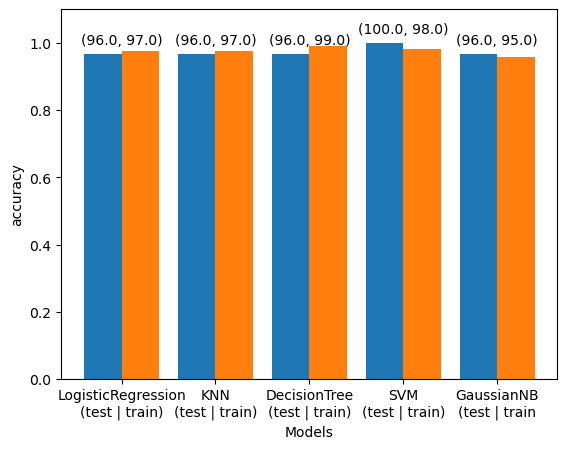

In [226]:
o=["LogisticRegression\n(test | train)","KNN\n(test | train)","DecisionTree\n(test | train)","SVM\n(test | train)","GaussianNB\n(test | train"]
x=np.array([1,2,3,4,5])
test_acc=[LR_test,KNN_test,DT_test,SVM_test,GNB_test]
train_acc=[LR_train,KNN_train,DT_train,SVM_train,GNB_train]
width=0.4
plt.bar(x-width/2,test_acc,width)
plt.bar(x+width/2,train_acc,width)
plt.xlabel("Models")
plt.ylabel("accuracy")
plt.ylim(0,max(test_acc)+0.1)
plt.xticks(x,o)
for i in range(len(x)):
    plt.text(x[i],test_acc[i]+0.03,str((test_acc[i]*100//1,train_acc[i]*100//1)),ha="center")

In [ ]:
# plt.text( x_pos , y_pos , text in string  , alignment (ha))
# xticks to change x labels 